In [1]:
import torch
import torch.nn as nn # Neural network modules
import torch.optim as optim # Optimization algorithms
from torch.utils.data import DataLoader, Dataset # Data handling utilities
from sklearn.datasets import fetch_20newsgroups # Dataset source
from sklearn.model_selection import train_test_split # Splitter
import re # Regular expressions for text cleaning
from collections import Counter # For counting word frequencies


# Device configuration (GPU, MPS, or CPU based on availability)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA (GPU)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using device: CPU")
    
# Select 4 specific categories to make the classification task clear
categories = ['sci.crypt', 'sci.electronics', 'sci.med', 'sci.space']

# Load the dataset while removing "headers", "footers", and "quotes" to avoid cheating (metadata)
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

texts = newsgroups.data # The raw text articles
labels = newsgroups.target # The integer category IDs (0 to 3)

print(f"Dataset Loaded. Total samples: {len(texts)}")

Using device: MPS (Apple Silicon GPU)
Dataset Loaded. Total samples: 3952


In [2]:
def basic_tokenizer(text):
    # Convert all text to lowercase for consistency
    text = text.lower()
    # Remove any character that isn't a letter, number, or space
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Split the string into individual words (tokens)
    return text.split()

# Build a global list of all tokens found in the entire dataset
all_tokens = []
for t in texts:
    all_tokens.extend(basic_tokenizer(t))

# Define the maximum size of our vocabulary (most common 10,000 words)
vocab_size = 10000
word_counts = Counter(all_tokens) # Count how many times each word appears
most_common_words = word_counts.most_common(vocab_size - 2) # Leave room for special tokens

# Map each word to a unique integer index starting from 2
word_to_idx = {word: i + 2 for i, (word, _) in enumerate(most_common_words)}
word_to_idx['<PAD>'] = 0  # Token used to fill short sentences to a fixed length
word_to_idx['<UNK>'] = 1  # Token used for words not found in our top 10,000 list

print(f"Vocabulary built with {len(word_to_idx)} unique tokens.")

Vocabulary built with 10000 unique tokens.


In [3]:
all_tokens[:10]

['they',
 'are',
 'and',
 'they',
 'have',
 'david',
 'stimulation',
 'of',
 'the',
 'vagus']

In [4]:
max_len = 100 # We will look at the first 100 words of every article

def encode_text(text):
    tokens = basic_tokenizer(text) # Split text into words
    # Convert words to IDs; use 1 (<UNK>) if word is missing from vocabulary
    encoded = [word_to_idx.get(token, 1) for token in tokens]
    
    # If the text is shorter than max_len, add <PAD> (0) tokens to the end
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        # If the text is longer, cut it off at max_len
        encoded = encoded[:max_len]
    return torch.tensor(encoded) # Return as a PyTorch Tensor

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        # Pre-encode all texts to save time during training
        self.texts = [encode_text(t) for t in texts]
        self.labels = torch.tensor(labels) # Convert labels list to Tensor
        
    def __len__(self):
        return len(self.labels) # Total number of items
    
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx] # Return a single data point

# Split the data into 80% Training and 20% Validation
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2)

# Create DataLoaders to handle batching and shuffling
train_loader = DataLoader(NewsDataset(train_texts, train_labels), batch_size=32, shuffle=True)
val_loader = DataLoader(NewsDataset(val_texts, val_labels), batch_size=32)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [5]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMClassifier, self).__init__()
        # Embedding: Converts word indices (0, 1, 2...) into dense vectors of size embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # LSTM: bidirectional=True processes sequence in both directions
        # batch_first=True means the input shape is (Batch, Sequence, Features)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # Linear Layer: Maps LSTM output to our 4 categories
        # hidden_dim * 2 because we have a forward and a backward hidden state
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
        # Dropout: Randomly turns off neurons during training to prevent overfitting
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Pass input word IDs through Embedding and Dropout
        embedded = self.dropout(self.embedding(x))
        
        # lstm_out contains all hidden states; hidden contains the final state of each direction
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Concatenate the final forward hidden state (hidden[-2]) and backward state (hidden[-1])
        cat_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        
        # Pass the concatenated states through dropout and the final linear layer
        return self.fc(self.dropout(cat_hidden))

# Instantiate the model
# vocab_size=10000, embedding=128, hidden=64, output=4 classes
model = BiLSTMClassifier(10000, 128, 64, 4).to(device)
criterion = nn.CrossEntropyLoss() # Loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Standard optimizer

print("Bi-LSTM Model Initialized.")

Bi-LSTM Model Initialized.


In [6]:
epochs = 5
print("Starting training...")

for epoch in range(epochs):
    model.train() # Set model to training mode (activates dropout)
    total_loss = 0
    
    for texts_batch, labels_batch in train_loader:
        texts_batch, labels_batch = texts_batch.to(device), labels_batch.to(device)
        
        optimizer.zero_grad() # Clear previous gradients
        outputs = model(texts_batch) # Forward pass (predict)
        loss = criterion(outputs, labels_batch) # Calculate error
        loss.backward() # Backward pass (calculate gradients)
        optimizer.step() # Update model weights
        
        total_loss += loss.item()
    
    # Calculate and print average loss for this epoch
    print(f"Epoch {epoch+1}/{epochs} | Average Training Loss: {total_loss/len(train_loader):.4f}")

Starting training...
Epoch 1/5 | Average Training Loss: 1.3895
Epoch 2/5 | Average Training Loss: 1.3501
Epoch 3/5 | Average Training Loss: 1.3030
Epoch 4/5 | Average Training Loss: 1.2135
Epoch 5/5 | Average Training Loss: 1.0862



CLASSIFICATION REPORT
                 precision    recall  f1-score   support

      sci.crypt       0.44      0.77      0.56       192
sci.electronics       0.52      0.51      0.51       203
        sci.med       0.47      0.31      0.37       200
      sci.space       0.40      0.26      0.32       196

       accuracy                           0.46       791
      macro avg       0.46      0.46      0.44       791
   weighted avg       0.46      0.46      0.44       791



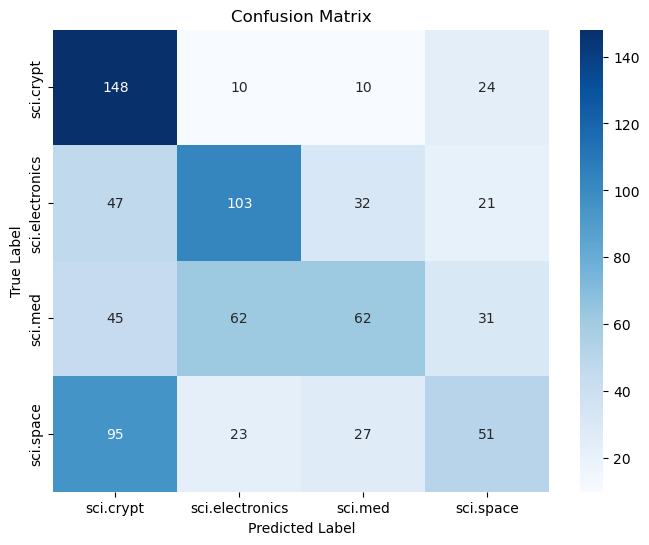

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # For a beautiful heatmap visualization
import matplotlib.pyplot as plt


def evaluate_model(model, loader):
    model.eval() # Switch to evaluation mode
    all_preds = [] # List to store model predictions
    all_labels = [] # List to store actual ground truth labels

    with torch.no_grad(): # Disable gradient tracking
        for texts_batch, labels_batch in loader:
            # Move data to the current device (CPU/GPU)
            texts_batch = texts_batch.to(device)
            
            # Get model output (raw logits)
            outputs = model(texts_batch)
            
            # Find the index of the highest score for each sample in the batch
            _, predicted = torch.max(outputs, 1)
            
            # Store predictions and labels as CPU-based numpy arrays
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.numpy())

    # 1. Print the Classification Report
    # This shows Precision, Recall, and F1-Score for each of the 4 classes
    print("\n" + "="*30)
    print("CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(all_labels, all_preds, target_names=categories))

    # 2. Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds) # Calculate the matrix
    plt.figure(figsize=(8, 6)) # Create a figure for plotting
    
    # Use Seaborn to create a heatmap for visual clarity
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=categories, yticklabels=categories)
    
    plt.xlabel('Predicted Label') # Label for X axis
    plt.ylabel('True Label')      # Label for Y axis
    plt.title('Confusion Matrix') # Title of the plot
    plt.show()

# Run the evaluation on the validation set
evaluate_model(model, val_loader)

In [9]:
def classify_text(user_input):
    model.eval() # Set model to evaluation mode (turns off dropout)
    with torch.no_grad(): # Disable gradient calculation for efficiency
        # 1. Preprocess and Pad the user's string
        encoded = encode_text(user_input).unsqueeze(0).to(device) # unsqueeze(0) adds a batch dimension
        
        # 2. Get prediction from model
        output = model(encoded)
        
        # 3. Find the index with the highest score
        _, predicted = torch.max(output, 1)
        
        # 4. Map index to category name
        category_name = categories[predicted.item()]
        
        # 5. Calculate probability (Confidence)
        probs = torch.softmax(output, dim=1)
        confidence = probs[0][predicted.item()].item()
        
    print(f"\nUser Input: '{user_input}'")
    print(f"Prediction: {category_name} ({confidence*100:.2f}% confidence)")

# Test the function with a new sentence
classify_text("New research suggests a new vaccine could help prevent common infections.")
classify_text("The satellite reached the lunar orbit successfully.")


User Input: 'New research suggests a new vaccine could help prevent common infections.'
Prediction: sci.electronics (32.31% confidence)

User Input: 'The satellite reached the lunar orbit successfully.'
Prediction: sci.crypt (46.66% confidence)
